# Hole states, band alignment and critical size

**The hole level sets the emission wavelength here.** In every antimonide system below the
electron is unbound — the confinement map finds no bound electron state — so the electron sits
at the matrix conduction edge and the transition is spatially indirect (type II):

$$E_\mathrm{transition} = E_c(\mathrm{far}) - E_\mathrm{hole}$$

In a **broken-gap** system that decides something more basic than the wavelength: whether there
is a transition at all. The dot's valence top lies *above* the matrix conduction edge by the
**offset**; confinement pushes the hole level down. If confinement does not exceed the offset,
electrons transfer out of the dot and the system is semimetallic. So

$$\boxed{\text{gap opens when confinement}(R) > \text{offset}}$$

and since the offset is size-independent, that is a condition on size alone.

## Why six-band, and why that is a correctness issue rather than a shortcut

The eight-band Hamiltonian couples conduction and valence, and on a finite-difference grid that
coupling produces **spurious solutions** — wrong-curvature branches at large $k$ that appear as
grid-scale-oscillatory states inside the gap. They are converged, exactly Kramers-paired, and
wrong.

Measured on the InAs/GaAs control (the type-I system whose bound holes are not in question), an
eight-band solve seeded at the exact island valence top converged to a **7.4e-08 eV residual**
and returned twelve states 14–52 meV below the edge, each with **0.6–0.8%** of its density in
the island — against a random-vector baseline of **8.2%**. Those states sit between the matrix
valence top (0.2351 eV) and the island valence top (0.3245 eV), classically forbidden in the
matrix, yet 99% of their weight is there. The same geometry solved six-band returns the ladder
at **80–97%** localization in **7 seconds**.

This was not $\sigma$ placement (the valence maximum is inside the island by 89–567 meV in every
system), not block size, and not convergence — all three were tested and excluded.

Six-band drops the conduction–valence coupling, which pushes valence states down, so it
**underestimates** hole confinement — mildly in InGaSb ($E_g = 0.42$ eV), more in InSb
($E_g = 0.235$ eV). Every confinement energy and critical size below is therefore
**conservative**: the true thresholds are likely somewhat larger, i.e. more favourable.

## Other caveats that travel with these numbers

- **Not grid-converged in absolute terms.** The sweep holds *cells per radius* fixed rather than
  $h$, so resolution per unit island is constant but $h$ itself varies.
- $T = 0$ K throughout (`materials` sets Varshni to 0 K at import).
- `e14` and $\varepsilon_r$ are not from Vurgaftman's own tables and `e14`'s sign disagrees with
  Pryor 1998. Set `USE_PIEZO = False` below to see what they are worth.
- Alloy electron masses are inconsistent in the source by 9–16%; this matters for the electron,
  not for the hole levels here.


## Parameters

**Change these and re-run the notebook.** `RADIUS` sets the reference island used for the band
alignment and level figures; `SWEEP_RADII` sets the critical-size scan.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import heterostructure as hs
import materials as mt

# ---- island -------------------------------------------------------------------------
RADIUS = 10.0          # lens base radius (nm) for the reference figures
ASPECT = 0.25          # height / diameter
USE_PIEZO = True

# ---- grid ---------------------------------------------------------------------------
CELLS_PER_RADIUS = 10.0   # h = RADIUS / this;  raise for accuracy, cost ~ n^1.5 or worse
PAD_FRAC = 0.4            # matrix padding as a fraction of RADIUS
MIN_H, MIN_PAD = 0.35, 3.0

# ---- alloys -------------------------------------------------------------------------
X_INGASB = 0.50        # In(x)Ga(1-x)Sb dot
Y_INASSB = 0.30        # InAs(1-y)Sb(y) matrix

# ---- critical-size sweep ------------------------------------------------------------
SWEEP_RADII = [4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0]

N_LEVELS = 8           # hole levels to solve for
HC = 1.23984193        # eV.um, for lambda = HC / E

INGASB = ('InGaSb', X_INGASB)
INASSB = ('InAsSb', Y_INASSB)
SYSTEMS = [
    (INGASB, 'InAs',   'InGaSb / InAs'),
    (INGASB, INASSB,   'InGaSb / InAsSb'),
    ('InSb', 'InAs',   'InSb / InAs'),
    ('InSb', INASSB,   'InSb / InAsSb'),
    ('InAs', 'GaAs',   'InAs / GaAs'),
]
COL = {'InGaSb / InAs': '#d62728', 'InGaSb / InAsSb': '#ff7f0e',
       'InSb / InAs': '#1f77b4', 'InSb / InAsSb': '#2ca02c',
       'InAs / GaAs': '#7f7f7f'}
# One hue per LEVEL (not per system); same hue = same level index in every figure.
LEVEL_PALETTE = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']


def make_env(dot, matrix, R, cells=None, verbose=False):
    """Strain + band edges for one (dot, matrix) at base radius R. Grid scales with R."""
    shape = hs.spherical_lens(R, 2 * R * ASPECT)
    h = max(R / (cells or CELLS_PER_RADIUS), MIN_H)
    pad = max(PAD_FRAC * R, MIN_PAD)
    return hs.build(shape, dot, matrix=matrix, h=h, pad=pad, use_piezo=USE_PIEZO,
                    vol_tol=0.35, verbose=verbose)


def hole_summary(env, k=N_LEVELS, verbose=False):
    """Six-band hole ladder plus the quantities that decide whether a gap is open."""
    r = hs.six_band_holes(env, k=k, verbose=verbose)
    top, Ec = r['top'], env['Ec_far']
    offset = (top - Ec) * 1e3
    conf = (top - r['E']) * 1e3
    Et = (Ec - r['E'][0]) * 1e3
    return dict(E=np.asarray(r['E']), loc=np.asarray(r['loc']), top=top, Ec_far=Ec,
                offset=offset, conf=conf, shortfall=offset - conf[0],
                transition=Et, lam=(HC / (Et * 1e-3) if Et > 0 else None),
                seconds=r['seconds'])

print(f"reference island: lens r = {RADIUS:g} nm, height {2*RADIUS*ASPECT:g} nm, "
      f"h = {max(RADIUS/CELLS_PER_RADIUS, MIN_H):.2f} nm")


reference island: lens r = 10 nm, height 5 nm, h = 1.00 nm


## 1. Band alignment at the reference size

Misfit, the strained band edges, and the **offset** each system has to beat. A positive offset
is a broken-gap (type III) alignment: the dot's valence top lies above the matrix conduction
edge, and nothing emits until confinement closes that.

In [2]:
ENVS, REF = {}, {}
print(f"{'system':<18} {'misfit':>8} {'v top':>8} {'Ec far':>8} {'offset':>9} "
      f"{'alignment':>16}")
print("-" * 74)
for dot, matrix, label in SYSTEMS:
    env = make_env(dot, matrix, RADIUS)
    ENVS[label] = env
    top = hs.valence_edge_top(env)
    offset = (top - env['Ec_far']) * 1e3
    kind = 'broken gap (III)' if offset > 0 else 'straddling / stag.'
    print(f"{label:<18} {mt.misfit(env['dot'], env['matrix'])*100:>7.2f}% {top:>8.4f} "
          f"{env['Ec_far']:>8.4f} {offset:>8.0f}m {kind:>16}")


system               misfit    v top   Ec far    offset        alignment
--------------------------------------------------------------------------


InGaSb / InAs        -3.59%   0.6665   0.4170      249m broken gap (III)


InGaSb / InAsSb      -1.59%   0.4376   0.2217      216m broken gap (III)


InSb / InAs          -6.48%   0.7913   0.4170      374m broken gap (III)


InSb / InAsSb        -4.53%   0.5519   0.2217      330m broken gap (III)


InAs / GaAs          -6.75%   0.3245   1.5190    -1194m straddling / stag.


### Strained band edges along the three principal directions

Where a band crosses the dashed/dotted matrix levels is where a well exists. Note the enormous
conduction barrier inside the antimonide dots — that is why no electron binds and the transition
has to be type II.

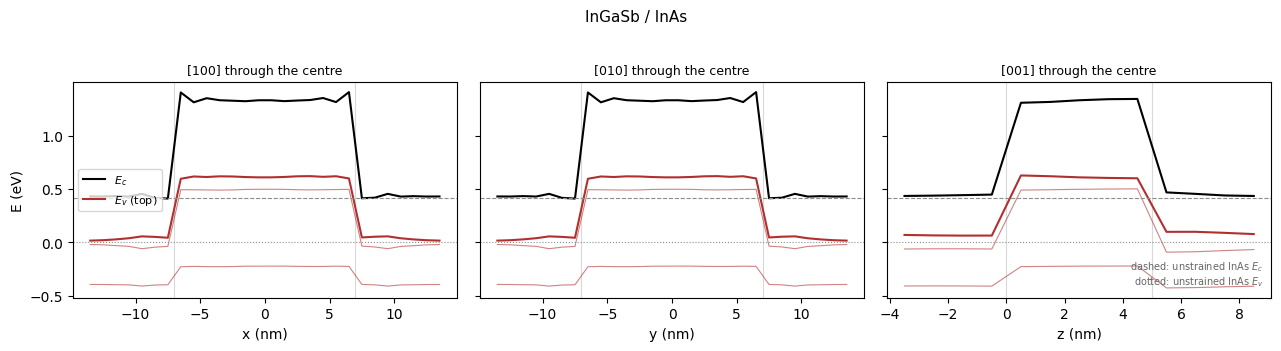

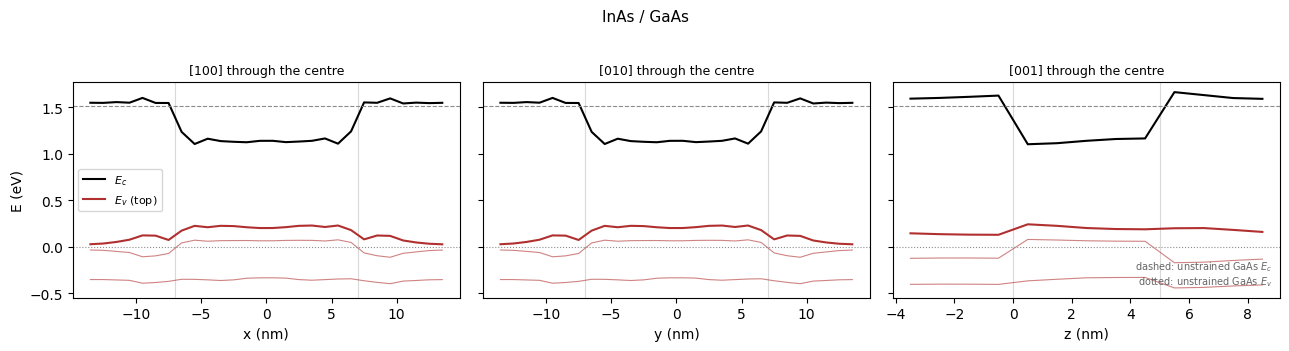

In [3]:
for label in ['InGaSb / InAs', 'InAs / GaAs']:
    fig = hs.plot_bands(ENVS[label], figsize=(13, 3.4))
    fig.suptitle(label, fontsize=11, y=1.02)
    plt.show()


## 2. Hole levels at the reference size

Six-band, seconds per system. `loc` is the fraction of $\sum_i|\psi_i|^2$ inside the island —
the quantity that distinguishes an island state from a box state, and the one the eight-band
solve failed.

In [4]:
for dot, matrix, label in SYSTEMS:
    r = hole_summary(ENVS[label])
    REF[label] = r
    lam = f"{r['lam']:.2f} um" if r['lam'] else "no gap"
    print(f"\n{label}   offset {r['offset']:+.0f} meV   ({r['seconds']:.0f}s)")
    for j in range(len(r['E'])):
        print(f"   h{j}: E = {r['E'][j]:+.4f} eV   conf {r['conf'][j]:6.1f} meV   "
              f"loc {r['loc'][j]*100:5.1f}%")
    print(f"   ground state: shortfall {r['shortfall']:+.0f} meV -> "
          f"{'GAP OPEN, lambda = ' + lam if r['transition'] > 0 else 'semimetallic (no gap)'}")



InGaSb / InAs   offset +249 meV   (10s)
   h0: E = +0.5299 eV   conf  136.6 meV   loc  96.6%
   h1: E = +0.5299 eV   conf  136.6 meV   loc  96.6%
   h2: E = +0.4923 eV   conf  174.1 meV   loc  95.9%
   h3: E = +0.4923 eV   conf  174.1 meV   loc  95.9%
   h4: E = +0.4778 eV   conf  188.6 meV   loc  93.6%
   h5: E = +0.4778 eV   conf  188.6 meV   loc  93.6%
   h6: E = +0.4547 eV   conf  211.8 meV   loc  94.9%
   h7: E = +0.4547 eV   conf  211.8 meV   loc  94.9%
   ground state: shortfall +113 meV -> semimetallic (no gap)



InGaSb / InAsSb   offset +216 meV   (11s)
   h0: E = +0.3332 eV   conf  104.4 meV   loc  94.8%
   h1: E = +0.3332 eV   conf  104.4 meV   loc  94.8%
   h2: E = +0.3038 eV   conf  133.7 meV   loc  93.4%
   h3: E = +0.3038 eV   conf  133.7 meV   loc  93.4%
   h4: E = +0.2862 eV   conf  151.3 meV   loc  90.1%
   h5: E = +0.2862 eV   conf  151.3 meV   loc  90.1%
   h6: E = +0.2727 eV   conf  164.9 meV   loc  91.7%
   h7: E = +0.2727 eV   conf  164.9 meV   loc  91.7%
   ground state: shortfall +111 meV -> semimetallic (no gap)



InSb / InAs   offset +374 meV   (6s)
   h0: E = +0.5996 eV   conf  191.7 meV   loc  96.0%
   h1: E = +0.5996 eV   conf  191.7 meV   loc  96.0%
   h2: E = +0.5507 eV   conf  240.6 meV   loc  94.9%
   h3: E = +0.5507 eV   conf  240.6 meV   loc  94.9%
   h4: E = +0.5444 eV   conf  246.8 meV   loc  93.1%
   h5: E = +0.5444 eV   conf  246.8 meV   loc  93.1%
   h6: E = +0.5052 eV   conf  286.1 meV   loc  93.9%
   h7: E = +0.5001 eV   conf  291.1 meV   loc  93.9%
   ground state: shortfall +183 meV -> semimetallic (no gap)



InSb / InAsSb   offset +330 meV   (6s)
   h0: E = +0.3965 eV   conf  155.4 meV   loc  94.4%
   h1: E = +0.3965 eV   conf  155.4 meV   loc  94.4%
   h2: E = +0.3537 eV   conf  198.2 meV   loc  92.9%
   h3: E = +0.3537 eV   conf  198.2 meV   loc  92.9%
   h4: E = +0.3464 eV   conf  205.5 meV   loc  89.7%
   h5: E = +0.3464 eV   conf  205.5 meV   loc  89.7%
   h6: E = +0.3135 eV   conf  238.5 meV   loc  91.0%
   h7: E = +0.3097 eV   conf  242.2 meV   loc  90.5%
   ground state: shortfall +175 meV -> semimetallic (no gap)



InAs / GaAs   offset -1194 meV   (6s)
   h0: E = +0.1829 eV   conf  141.6 meV   loc  90.8%
   h1: E = +0.1829 eV   conf  141.6 meV   loc  90.8%
   h2: E = +0.1649 eV   conf  159.6 meV   loc  84.9%
   h3: E = +0.1649 eV   conf  159.6 meV   loc  84.9%
   h4: E = +0.1502 eV   conf  174.3 meV   loc  87.6%
   h5: E = +0.1502 eV   conf  174.3 meV   loc  87.6%
   h6: E = +0.1452 eV   conf  179.4 meV   loc  80.1%
   h7: E = +0.1452 eV   conf  179.4 meV   loc  80.1%
   ground state: shortfall -1336 meV -> GAP OPEN, lambda = 0.93 um


### Where the levels sit, in space

Each level is drawn across its **classically allowed region** — computed from the potential, not
placed by hand, so it cannot silently disagree with the wavefunction. A level that is not bound
is drawn dotted and spans the whole box, because that is what it does.

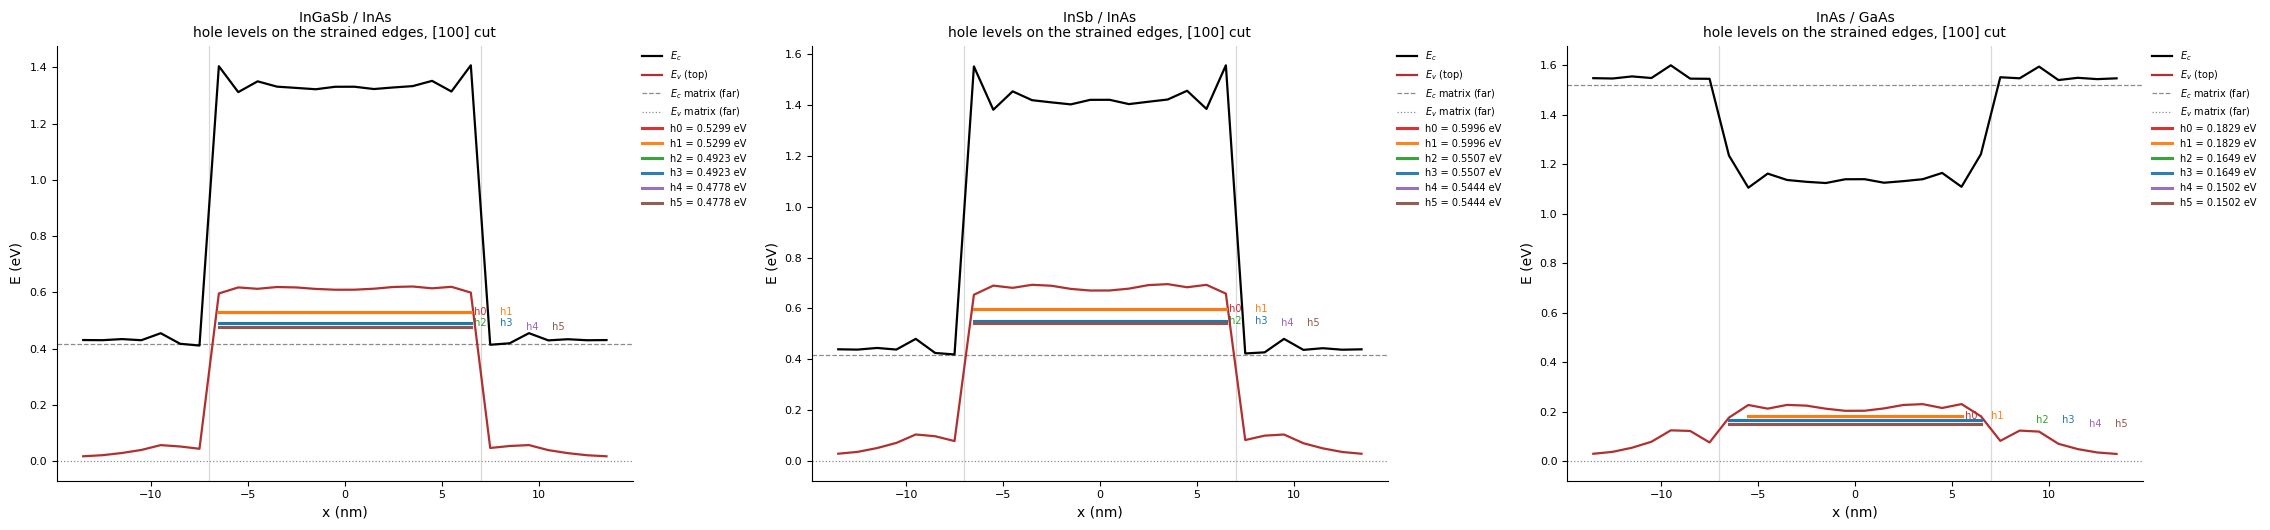

In [5]:
SHOW = ['InGaSb / InAs', 'InSb / InAs', 'InAs / GaAs']
fig, axes = plt.subplots(1, len(SHOW), figsize=(7.6 * len(SHOW), 5.4), squeeze=False)
for ax, label in zip(axes[0], SHOW):
    hs.plot_levels(ENVS[label], hole=dict(E=REF[label]['E']), cut='x', ax=ax,
                   max_levels=6, palette=LEVEL_PALETTE)
    ax.set_title(f"{label}\nhole levels on the strained edges, [100] cut", fontsize=10)
fig.tight_layout()
plt.show()


### The energy budget

Confinement measured downward from the dot's valence top, against the offset each system must
clear. Shaded = a gap is open. Line weight is localization, so a thin line is a state
hybridized with the matrix continuum rather than a clean island state.

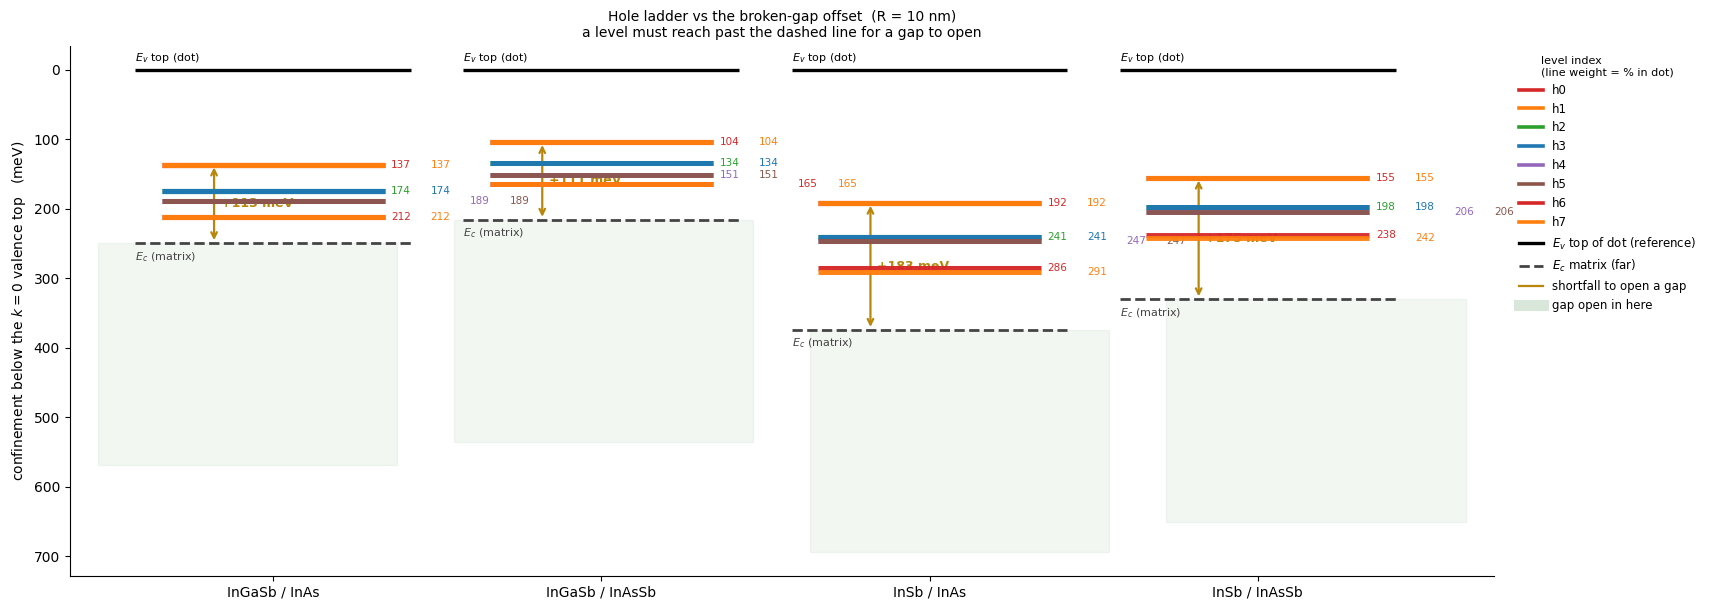

In [6]:
have = [(l, REF[l]) for _, _, l in SYSTEMS if REF[l]['offset'] > 0]
fig, ax = plt.subplots(figsize=(3.2 * len(have) + 4.4, 6.2))
nmax = 0
for i, (label, r) in enumerate(have):
    offset = r['offset']
    nmax = max(nmax, len(r['E']))
    ax.hlines(0.0, i - 0.42, i + 0.42, color='k', lw=2.4, zorder=5)
    ax.annotate('$E_v$ top (dot)', (i - 0.42, -12), fontsize=8, color='k')
    ax.hlines(offset, i - 0.42, i + 0.42, color='#444444', lw=2.0, ls='--', zorder=5)
    ax.annotate('$E_c$ (matrix)', (i - 0.42, offset + 24), fontsize=8, color='#444444')
    ax.axhspan(offset, offset + 320, xmin=(i + 0.08) / len(have),
               xmax=(i + 0.92) / len(have), color='#2e7d32', alpha=0.06, zorder=0)

    placed = []
    for j, (cf, l) in enumerate(zip(r['conf'], r['loc'])):
        col = LEVEL_PALETTE[j % len(LEVEL_PALETTE)]
        ax.hlines(cf, i - 0.34, i + 0.34, color=col, lw=1.0 + 2.8 * l,
                  alpha=0.4 + 0.6 * l, zorder=4)
        step = 0                      # doublets sit within a few meV; stagger their labels
        while any(abs(cf - pc) < 16.0 and step == ps for pc, ps in placed):
            step += 1
        placed.append((cf, step))
        ax.annotate(f"{cf:.0f}", (i + 0.36 + 0.12 * step, cf), fontsize=7.5,
                    va='center', color=col)

    ax.annotate('', xy=(i - 0.18, offset), xytext=(i - 0.18, r['conf'][0]),
                arrowprops=dict(arrowstyle='<->', color='#b8860b', lw=1.6))
    ax.annotate(f"{r['shortfall']:+.0f} meV", (i - 0.16, (r['conf'][0] + offset) / 2),
                fontsize=9, color='#b8860b', va='center', fontweight='bold')

handles = [Line2D([], [], color=LEVEL_PALETTE[j % len(LEVEL_PALETTE)], lw=2.6, label=f"h{j}")
           for j in range(nmax)]
handles += [Line2D([], [], color='k', lw=2.4, label='$E_v$ top of dot (reference)'),
            Line2D([], [], color='#444444', lw=2.0, ls='--', label='$E_c$ matrix (far)'),
            Line2D([], [], color='#b8860b', lw=1.6, label='shortfall to open a gap'),
            Line2D([], [], color='#2e7d32', lw=8, alpha=0.18, label='gap open in here')]
leg = ax.legend(handles=handles, fontsize=8.5, loc='upper left', bbox_to_anchor=(1.01, 1.0),
                frameon=False, title='level index\n(line weight = % in dot)')
leg.get_title().set_fontsize(8.0)
ax.set_xticks(range(len(have)))
ax.set_xticklabels([l for l, _ in have], fontsize=10)
ax.set_xlim(-0.62, len(have) - 0.28)
ax.set_ylabel('confinement below the $k=0$ valence top   (meV)')
ax.invert_yaxis()
ax.set_title(f'Hole ladder vs the broken-gap offset  (R = {RADIUS:g} nm)\n'
             'a level must reach past the dashed line for a gap to open', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 3. Critical size — the main result

The offset is **size-independent**: continuum elasticity has no length scale, so at fixed shape
the strained band edges do not move with size. Only confinement moves. The gap therefore opens
where $\text{confinement}(R) = \text{offset}$, and one sweep in $R$ brackets it.

That the offset stays constant across the sweep is also a free consistency check on the
elasticity — watch the `offset` column.

In [7]:
SWEEP = {}
t0 = time.time()
for dot, matrix, label in SYSTEMS:
    rows = []
    for R in SWEEP_RADII:
        env = make_env(dot, matrix, R)
        r = hole_summary(env, k=2)
        rows.append(dict(R=R, offset=r['offset'], conf=r['conf'][0], loc=r['loc'][0],
                         shortfall=r['shortfall'], sites=int(env['mask'].size)))
    SWEEP[label] = rows
    print(f"{label}")
    for d in rows:
        print(f"   R={d['R']:5.1f} nm  offset {d['offset']:+7.1f}  conf {d['conf']:7.1f}  "
              f"shortfall {d['shortfall']:+7.1f} meV  loc {d['loc']*100:4.1f}%"
              f"{'   GAP OPEN' if d['shortfall'] < 0 else ''}")
print(f"\ntotal {time.time()-t0:.0f}s")


InGaSb / InAs
   R=  4.0 nm  offset  +255.1  conf   341.5  shortfall   -86.4 meV  loc 80.5%   GAP OPEN
   R=  5.0 nm  offset  +253.4  conf   275.0  shortfall   -21.6 meV  loc 86.7%   GAP OPEN
   R=  6.0 nm  offset  +251.5  conf   229.0  shortfall   +22.5 meV  loc 90.6%
   R=  7.0 nm  offset  +249.0  conf   197.2  shortfall   +51.8 meV  loc 93.1%
   R=  8.0 nm  offset  +249.1  conf   171.5  shortfall   +77.7 meV  loc 94.6%
   R= 10.0 nm  offset  +249.5  conf   136.6  shortfall  +112.9 meV  loc 96.6%
   R= 12.0 nm  offset  +249.8  conf   114.4  shortfall  +135.3 meV  loc 97.7%


InGaSb / InAsSb
   R=  4.0 nm  offset  +218.4  conf   278.2  shortfall   -59.8 meV  loc 72.7%   GAP OPEN
   R=  5.0 nm  offset  +217.6  conf   224.7  shortfall    -7.1 meV  loc 81.0%   GAP OPEN
   R=  6.0 nm  offset  +216.8  conf   186.3  shortfall   +30.5 meV  loc 86.2%
   R=  7.0 nm  offset  +215.7  conf   158.8  shortfall   +56.9 meV  loc 89.9%
   R=  8.0 nm  offset  +215.7  conf   135.7  shortfall   +80.0 meV  loc 92.0%
   R= 10.0 nm  offset  +215.9  conf   104.4  shortfall  +111.5 meV  loc 94.8%
   R= 12.0 nm  offset  +216.0  conf    84.4  shortfall  +131.6 meV  loc 96.4%


InSb / InAs
   R=  4.0 nm  offset  +385.1  conf   343.4  shortfall   +41.7 meV  loc 67.8%
   R=  5.0 nm  offset  +381.6  conf   318.4  shortfall   +63.2 meV  loc 86.5%
   R=  6.0 nm  offset  +378.1  conf   279.9  shortfall   +98.3 meV  loc 90.3%
   R=  7.0 nm  offset  +373.6  conf   252.1  shortfall  +121.6 meV  loc 92.6%
   R=  8.0 nm  offset  +373.8  conf   227.0  shortfall  +146.8 meV  loc 94.1%
   R= 10.0 nm  offset  +374.3  conf   191.7  shortfall  +182.6 meV  loc 96.0%
   R= 12.0 nm  offset  +374.7  conf   168.3  shortfall  +206.4 meV  loc 97.2%


InSb / InAsSb
   R=  4.0 nm  offset  +337.9  conf   321.9  shortfall   +16.0 meV  loc 74.8%
   R=  5.0 nm  offset  +335.5  conf   273.6  shortfall   +61.8 meV  loc 82.3%
   R=  6.0 nm  offset  +333.1  conf   236.8  shortfall   +96.2 meV  loc 86.8%
   R=  7.0 nm  offset  +329.8  conf   210.9  shortfall  +118.9 meV  loc 89.9%
   R=  8.0 nm  offset  +330.0  conf   187.7  shortfall  +142.2 meV  loc 91.8%
   R= 10.0 nm  offset  +330.2  conf   155.4  shortfall  +174.8 meV  loc 94.4%
   R= 12.0 nm  offset  +330.5  conf   134.3  shortfall  +196.2 meV  loc 95.9%


InAs / GaAs
   R=  4.0 nm  offset -1180.4  conf    -8.6  shortfall -1171.8 meV  loc 53.8%   GAP OPEN
   R=  5.0 nm  offset -1184.9  conf   138.9  shortfall -1323.8 meV  loc 56.6%   GAP OPEN
   R=  6.0 nm  offset -1189.3  conf   180.9  shortfall -1370.3 meV  loc 80.5%   GAP OPEN
   R=  7.0 nm  offset -1195.1  conf   171.7  shortfall -1366.8 meV  loc 85.1%   GAP OPEN
   R=  8.0 nm  offset -1194.9  conf   159.7  shortfall -1354.6 meV  loc 87.6%   GAP OPEN
   R= 10.0 nm  offset -1194.5  conf   141.6  shortfall -1336.1 meV  loc 90.8%   GAP OPEN
   R= 12.0 nm  offset -1194.1  conf   128.8  shortfall -1322.9 meV  loc 92.6%   GAP OPEN

total 479s


In [8]:
def critical_radius(rows):
    """Linear interpolation of the shortfall zero crossing. None if it does not cross."""
    for a, b in zip(rows, rows[1:]):
        if a['shortfall'] * b['shortfall'] < 0:
            t = a['shortfall'] / (a['shortfall'] - b['shortfall'])
            return a['R'] + t * (b['R'] - a['R'])
    return None

print(f"{'system':<20} {'critical R':>12}   dimensions at threshold")
print("-" * 68)
CRIT = {}
for label, rows in SWEEP.items():
    rc = critical_radius(rows)
    CRIT[label] = rc
    if rc is None:
        state = ('gap open at every size sampled' if rows[-1]['shortfall'] < 0
                 else f"never opens down to R = {rows[0]['R']:g} nm "
                      f"({rows[0]['shortfall']:+.0f} meV)")
        print(f"{label:<20} {'--':>12}   {state}")
    else:
        print(f"{label:<20} {rc:>10.2f} nm   diameter {2*rc:.1f} nm, "
              f"height {2*rc*ASPECT:.1f} nm")


system                 critical R   dimensions at threshold
--------------------------------------------------------------------
InGaSb / InAs              5.49 nm   diameter 11.0 nm, height 2.7 nm
InGaSb / InAsSb            5.19 nm   diameter 10.4 nm, height 2.6 nm
InSb / InAs                    --   never opens down to R = 4 nm (+42 meV)
InSb / InAsSb                  --   never opens down to R = 4 nm (+16 meV)
InAs / GaAs                    --   gap open at every size sampled


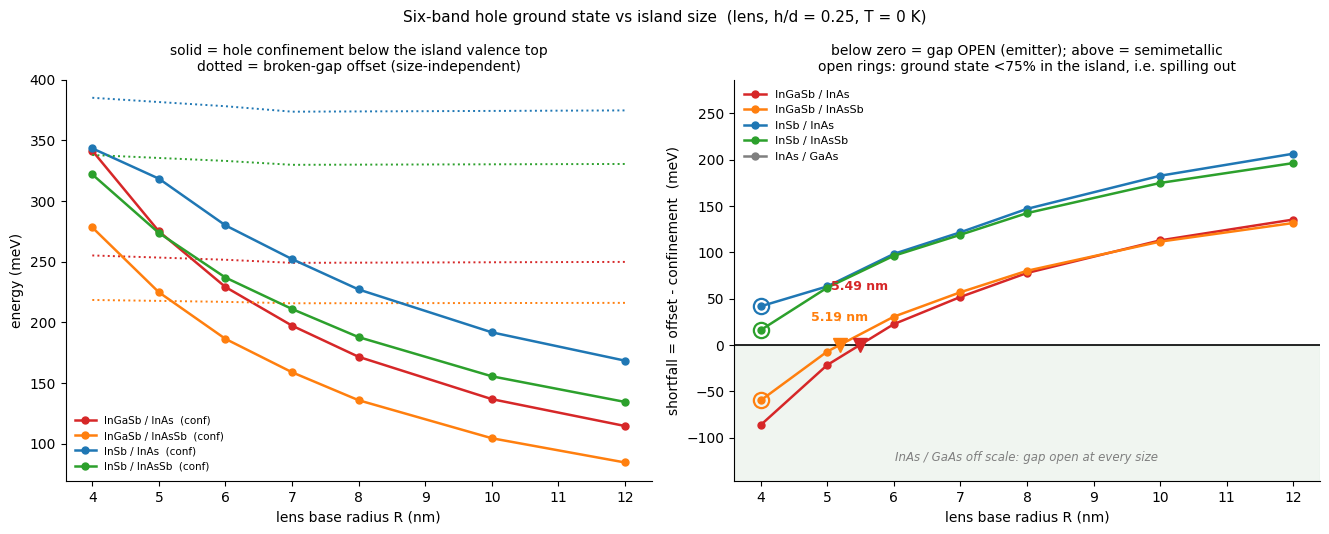

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.4, 5.4))
for label, rows in SWEEP.items():
    R = np.array([d['R'] for d in rows])
    conf = np.array([d['conf'] for d in rows])
    off = np.array([d['offset'] for d in rows])
    short = np.array([d['shortfall'] for d in rows])
    loc = np.array([d['loc'] for d in rows])
    col = COL[label]
    if REF[label]['offset'] > 0:
        a1.plot(R, conf, 'o-', color=col, lw=1.8, ms=5, label=f"{label}  (conf)")
        a1.plot(R, off, ':', color=col, lw=1.4)
    a2.plot(R, short, 'o-', color=col, lw=1.8, ms=5, label=label)
    soft = loc < 0.75          # ground state spilling out: extrapolation past here is unsafe
    if soft.any():
        a2.plot(R[soft], short[soft], 'o', color=col, ms=11, mfc='none', mew=1.6)

a1.set_xlabel('lens base radius R (nm)'); a1.set_ylabel('energy (meV)')
a1.set_title('solid = hole confinement below the island valence top\n'
             'dotted = broken-gap offset (size-independent)', fontsize=10)
a1.legend(fontsize=7.5, frameon=False)
a1.spines[['top', 'right']].set_visible(False)

a2.axhline(0, color='k', lw=1.2)
a2.axhspan(-4000, 0, color='#2e7d32', alpha=0.07)
finite = [d['shortfall'] for rows in SWEEP.values() for d in rows
          if abs(d['shortfall']) < 500]
a2.set_ylim(min(finite) - 60, max(finite) + 80)
a2.set_xlabel('lens base radius R (nm)')
a2.set_ylabel('shortfall = offset - confinement  (meV)')
a2.set_title('below zero = gap OPEN (emitter); above = semimetallic\n'
             'open rings: ground state <75% in the island, i.e. spilling out', fontsize=10)
a2.legend(fontsize=8, frameon=False, loc='upper left')
a2.spines[['top', 'right']].set_visible(False)

for j, (label, rc) in enumerate(sorted([(l, r) for l, r in CRIT.items() if r],
                                       key=lambda kv: kv[1])):
    a2.plot([rc], [0], 'v', color=COL[label], ms=10, zorder=6)
    a2.annotate(f"{rc:.2f} nm", (rc, 26 + 34 * j), color=COL[label], fontsize=9,
                ha='center', fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=COL[label], lw=0.8, shrinkB=6))
off_scale = [l for l, rows in SWEEP.items() if abs(rows[-1]['shortfall']) >= 500]
if off_scale:
    a2.annotate(', '.join(off_scale) + ' off scale: gap open at every size',
                (0.5, 0.05), xycoords='axes fraction', ha='center', fontsize=8.5,
                color='#7f7f7f', style='italic')

fig.suptitle(f'Six-band hole ground state vs island size  '
             f'(lens, h/d = {ASPECT:g}, T = 0 K)', fontsize=11)
fig.tight_layout()
plt.show()


## 4. Summary and what to trust

In [10]:
print(f"{'system':<20} {'offset':>8} {'conf@ref':>9} {'shortfall':>10} {'critical R':>11} "
      f"{'lambda':>9}")
print("-" * 74)
for _, _, label in SYSTEMS:
    r, rc = REF[label], CRIT[label]
    lam = f"{r['lam']:.2f} um" if r['lam'] else "no gap"
    rcs = f"{rc:.2f} nm" if rc else ('always open' if r['transition'] > 0 else 'not reached')
    print(f"{label:<20} {r['offset']:>7.0f}m {r['conf'][0]:>8.0f}m "
          f"{r['shortfall']:>+9.0f}m {rcs:>11} {lam:>9}")
print(f"\nreference island: R = {RADIUS:g} nm ({2*RADIUS:g} nm diameter, "
      f"{2*RADIUS*ASPECT:g} nm high)")


system                 offset  conf@ref  shortfall  critical R    lambda
--------------------------------------------------------------------------
InGaSb / InAs            249m      137m      +113m     5.49 nm    no gap
InGaSb / InAsSb          216m      104m      +111m     5.19 nm    no gap
InSb / InAs              374m      192m      +183m not reached    no gap
InSb / InAsSb            330m      155m      +175m not reached    no gap
InAs / GaAs            -1194m      142m     -1336m always open   0.93 um

reference island: R = 10 nm (20 nm diameter, 5 nm high)


### Reading these numbers honestly

1. **Six-band underestimates confinement**, so the critical sizes are conservative — the true
   thresholds are likely a little larger, i.e. easier to reach. The effect scales inversely with
   $E_g$, so it is smallest for InGaSb and largest for InSb, which is also where the answer is
   most marginal.
2. **Open rings on the right panel mark where the ground state has fallen below 75%
   localization** — the state is spilling out because the finite well is running out of depth
   faster than confinement is growing. The curves flatten there. Extrapolating a critical size
   past the last open ring is not safe.
3. **Confinement does not scale as $1/L^2$.** Over a 3$\times$ size change it moves by roughly
   3$\times$, i.e. closer to $1/L$, precisely because the well is finite and the state spills.
   A $1/L^2$ extrapolation from a single size overestimates the critical radius substantially.
4. **The offset column is a consistency check.** It should be size-independent; drift beyond a
   few meV means the strain solve or the box is not converged at that size.
5. **Not grid-converged in absolute terms.** Raise `CELLS_PER_RADIUS` and re-run to see the
   movement; the sweep holds resolution *per unit island* fixed, not $h$.